<div align="center">

<h1> <b> THERMALLY ACTIVATED SURFACE RELAXATION MODEL </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y Objetivos

En los notebooks anteriores exploramos la Deposición Aleatoria Pura (RD), gobernada puramente por la estadística estocástica de Poisson, y la Deposición Aleatoria con Relajación Superficial (RDSR), donde un mecanismo geométrico determinista reducía drásticamente la rugosidad al forzar a los adátomos a ocupar mínimos locales de altura. No obstante, ambos modelos carecen de una variable física crucial en cualquier cámara de evaporación real: la **temperatura del sustrato ($T$)**.

En este tercer notebook implementaremos un modelo de **Deposición con Difusión Superficial Activada Térmicamente**. Aquí, la movilidad de los átomos de cobre sobre el vidrio dejará de ser una regla geométrica idealizada e infinita; en su lugar, estará condicionada por la energía térmica disponible en el entorno, permitiendo modelar cómo el calentamiento o enfriamiento controlado del sustrato altera de forma dinámica y gradual la microestructura, homogeneidad y rugosidad final de la película delgada.

### Objetivos:
* Desarrollar e implementar un algoritmo estocástico de caminata aleatoria superficial cuya probabilidad de salto dependa de la temperatura del sustrato.
* Evaluar mediante múltiples réplicas estadísticas la influencia de la temperatura ($250\text{ K}$ a $700\text{ K}$) sobre la rugosidad RMS y los límites morfológicos de la película.
* Extraer y comparar las firmas morfológicas tradicionales (perfiles unidimensionales, mapas de calor, histogramas y evolución temporal) bajo condiciones de activación térmica variables.

## 2. Marco Teórico y Modelo Físico

Cuando un adátomo incide sobre el sustrato, interactúa con el potencial periódico generado por la red atómica subyacente (Venables, 2000). Para desplazarse hacia un sitio vecino, el átomo debe vencer una barrera de energía de difusión ($E_a$). La tasa de saltos térmicos suele describirse mediante una ley de tipo Arrhenius (Arrhenius, 1889):
$$\nu = \nu_0 \exp\left(-\frac{E_a}{k_B T}\right)$$

Para capturar la esencia cualitativa de este fenómeno sin incurrir en los costos computacionales extremos de escalas de tiempo microscópicas, modelaremos el proceso mediante una **probabilidad efectiva de difusión** normalizada $P(T)$, definida como:
$$P(T) = \frac{T}{T + T_0}$$
Donde $T$ es la temperatura absoluta del sustrato y $T_0 = 300\text{ K}$ es la temperatura característica de escala. Esta función describe matemáticamente un comportamiento asintótico ideal:
* Si $T \rightarrow 0\text{ K}$, entonces $P(T) \rightarrow 0$ (el sistema se comporta como Deposición Aleatoria pura).
* Si $T \rightarrow \infty\text{ K}$, entonces $P(T) \rightarrow 1$ (máxima movilidad atómica).

### Reglas de la Caminata Aleatoria Térmica:
1. Una partícula incide en una coordenada aleatoria $(x, y)$.
2. Se evalúa de manera estocástica si ocurre un salto de difusión con probabilidad $P(T)$. Si el intento falla, la partícula se deposita definitivamente.
3. Si el intento tiene éxito, inspecciona sus 4 vecinos de Von Neumann (arriba, abajo, izquierda, derecha). Un vecino es considerado accesible si su altura cumple que $h_{vecino} \le h_{actual} + 1$, emulando una difusión local con tendencia hacia los valles.
4. La partícula selecciona al azar uno de los vecinos válidos y se desplaza hacia él.
5. El proceso se repite cíclicamente hasta un máximo de $20$ pasos o hasta que la partícula quede atrapada o intente volver a un sitio ya visitado en su caminata actual (evitando bucles infinitos de retroceso).

In [1]:
# =============================================================================
# SECCIÓN 3: LIBRERÍAS Y CONFIGURACIÓN VISUAL
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numba as nb

# Fijamos la semilla aleatoria global para reproducibilidad estadística
np.random.seed(42)

# Ajustes de estilo para gráficas con calidad de publicación científica
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120
})

In [2]:
# =============================================================================
# SECCIÓN 4: PARÁMETROS GENERALES DEL EXPERIMENTO COMPUTACIONAL
# =============================================================================

# Configuración geométrica del sustrato
NX = 200
NY = 200

# Parámetros estocásticos de Monte Carlo
N_EVENTOS = 100000        # Número de partículas por simulación
N_REPLICAS = 10           # Réplicas independientes por cada temperatura
GUARDAR_CADA = 2000       # Frecuencia de muestreo temporal para diagnóstico

# Espectro de temperaturas a evaluar en el laboratorio virtual (en Kelvin)
TEMPERATURES = [250, 300, 350, 400, 500, 600, 700]

# Constantes físicas y de movilidad
T0 = 300                  # Temperatura de escala característica (K)
MAX_DIFFUSION_STEPS = 20  # Límite físico de saltos por adátomo

In [3]:
# =============================================================================
# SECCIÓN 5: ALGORITMOS FÍSICOS OPTIMIZADOS CON NUMBA
# =============================================================================

@nb.njit
def calcular_metricas_numba(superficie, nx, ny):
    """Calcula eficientemente el espesor medio y la rugosidad RMS."""
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)
    
    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diff = superficie[i, j] - espesor
            suma_varianza += diff * diff
    rugosidad = np.sqrt(suma_varianza / (nx * ny))
    return espesor, rugosidad


@nb.njit
def difundir_particula_termica(superficie, x_init, y_init, nx, ny, temp, t0, max_pasos):
    """
    Simula la caminata aleatoria activada térmicamente para un adátomo.
    Maneja condiciones de frontera abiertas y evita la auto-intersección de la ruta.
    """
    curr_x = x_init
    curr_y = y_init
    
    # Arreglos de tamaño fijo para registrar el historial de coordenadas visitadas (Numba-compliant)
    visitados_x = np.empty(max_pasos + 1, dtype=nb.int32)
    visitados_y = np.empty(max_pasos + 1, dtype=nb.int32)
    visitados_x[0] = curr_x
    visitados_y[0] = curr_y
    conteo_visitados = 1
    
    # Desplazamientos de Von Neumann: [Izquierda, Derecha, Abajo, Arriba]
    dx = (-1, 1, 0, 0)
    dy = (0, 0, -1, 1)
    
    # Probabilidad efectiva de Arrhenius simplificada
    p_difusion = temp / (temp + t0)
    
    for _ in range(max_pasos):
        # Criterio estocástico de activación térmica
        if np.random.random() >= p_difusion:
            break
            
        # Altura de corte permitida según la regla del modelo
        h_limite = superficie[curr_x, curr_y] + 1
        
        # Filtrado de vecinos válidos
        vecinos_validos_x = np.empty(4, dtype=nb.int32)
        vecinos_validos_y = np.empty(4, dtype=nb.int32)
        conteo_validos = 0
        
        for i in range(4):
            nx_c = curr_x + dx[i]
            ny_c = curr_y + dy[i]
            if 0 <= nx_c < nx and 0 <= ny_c < ny:
                if superficie[nx_c, ny_c] <= h_limite:
                    vecinos_validos_x[conteo_validos] = nx_c
                    vecinos_validos_y[conteo_validos] = ny_c
                    conteo_validos += 1
                    
        # Si no hay posiciones energéticamente accesibles, el átomo se detiene
        if conteo_validos == 0:
            break
            
        # Selección equiprobable del próximo sitio
        idx_elegido = np.random.randint(0, conteo_validos)
        next_x = vecinos_validos_x[idx_elegido]
        next_y = vecinos_validos_y[idx_elegido]
        
        # Control de lazo: verificar si el sitio ya fue pisado en esta caminata
        ya_visitado = False
        for v in range(conteo_visitados):
            if visitados_x[v] == next_x and visitados_y[v] == next_y:
                ya_visitado = True
                break
                
        if ya_visitado:
            break
            
        # Actualización de posición
        curr_x = next_x
        curr_y = next_y
        visitados_x[conteo_visitados] = curr_x
        visitados_y[conteo_visitados] = curr_y
        conteo_visitados += 1
        
    return curr_x, curr_y


@nb.njit
def ejecutar_simulacion_termica(nx, ny, n_eventos, temp, t0, max_pasos):
    """Ejecuta una simulación macroscópica estándar sin almacenar historial temporal."""
    superficie = np.zeros((nx, ny), dtype=nb.int32)
    for _ in range(n_eventos):
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)
        x_f, y_f = difundir_particula_termica(superficie, x_i, y_i, nx, ny, temp, t0, max_pasos)
        superficie[x_f, y_f] += 1
    return superficie


@nb.njit
def ejecutar_simulacion_termica_con_historial(nx, ny, n_eventos, temp, t0, max_pasos, guardar_cada):
    """Ejecuta la simulación guardando la evolución cronológica de las métricas."""
    superficie = np.zeros((nx, ny), dtype=nb.int32)
    tamano_hist = n_eventos // guardar_cada
    
    hist_eventos = np.zeros(tamano_hist, dtype=nb.int32)
    hist_espesor = np.zeros(tamano_hist, dtype=nb.float64)
    hist_rugosidad = np.zeros(tamano_hist, dtype=nb.float64)
    
    idx_hist = 0
    for evento in range(1, n_eventos + 1):
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)
        x_f, y_f = difundir_particula_termica(superficie, x_i, y_i, nx, ny, temp, t0, max_pasos)
        superficie[x_f, y_f] += 1
        
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_numba(superficie, nx, ny)
            hist_eventos[idx_hist] = evento
            hist_espesor[idx_hist] = esp
            hist_rugosidad[idx_hist] = rug
            idx_hist += 1
            
    return superficie, hist_eventos, hist_espesor, hist_rugosidad

In [4]:
# =============================================================================
# SECCIÓN 6: EJECUCIÓN DEL EXPERIMENTO MULTITEMPERATURA (RÉPLICAS)
# =============================================================================

lista_resultados = []

# Guardaremos tres matrices específicas para realizar la comparación morfológica visual posterior
superficie_250 = None
superficie_400 = None
superficie_700 = None

for temp in TEMPERATURES:
    print(f"Simulando espectro térmico: T = {temp} K...")
    
    arr_rugosidades = np.zeros(N_REPLICAS)
    arr_espesores = np.zeros(N_REPLICAS)
    arr_maximos = np.zeros(N_REPLICAS)
    arr_minimos = np.zeros(N_REPLICAS)
    
    for r in range(N_REPLICAS):
        matriz_res = ejecutar_simulacion_termica(NX, NY, N_EVENTOS, temp, T0, MAX_DIFFUSION_STEPS)
        
        arr_espesores[r] = np.mean(matriz_res)
        arr_rugosidades[r] = np.std(matriz_res)
        arr_maximos[r] = np.max(matriz_res)
        arr_minimos[r] = np.min(matriz_res)
        
        # Almacenamiento estratégico de muestras morfológicas para inspección visual
        if r == 0:
            if temp == 250:
                superficie_250 = matriz_res.copy()
            elif temp == 400:
                superficie_400 = matriz_res.copy()
            elif temp == 700:
                superficie_700 = matriz_res.copy()
                
    # Consolidación estadística de la temperatura actual
    lista_resultados.append({
        "Temperature": temp,
        "Mean thickness": np.mean(arr_espesores),
        "Thickness std": np.std(arr_espesores),
        "Mean roughness": np.mean(arr_rugosidades),
        "Roughness std": np.std(arr_rugosidades),
        "Maximum height": np.mean(arr_maximos),
        "Maximum std": np.std(arr_maximos),
        "Minimum height": np.mean(arr_minimos),
        "Minimum std": np.std(arr_minimos)
    })

print("Experimento multitemperatura finalizado con éxito")

Simulando espectro térmico: T = 250 K...
Simulando espectro térmico: T = 300 K...
Simulando espectro térmico: T = 350 K...
Simulando espectro térmico: T = 400 K...
Simulando espectro térmico: T = 500 K...
Simulando espectro térmico: T = 600 K...
Simulando espectro térmico: T = 700 K...
Experimento multitemperatura finalizado con éxito


In [5]:
# =============================================================================
# SECCIÓN 7: CONSTRUCCIÓN Y DESPLIEGUE DEL DATA-FRAME ESTADÍSTICO
# =============================================================================

df_resultados = pd.DataFrame(lista_resultados)
# Desplegar la tabla formateada a 3 decimales en el Notebook
df_resultados.round(3)

,Temperature,Mean thickness,Thickness std,Mean roughness,Roughness std,Maximum height,Maximum std,Minimum height,Minimum std
0,250,2.5,0.0,1.334,0.004,9.3,0.458,0.0,0.0
1,300,2.5,0.0,1.306,0.004,9.0,0.000,0.0,0.0
2,350,2.5,0.0,1.290,0.005,8.9,0.700,0.0,0.0
3,400,2.5,0.0,1.268,0.004,8.4,0.490,0.0,0.0
4,500,2.5,0.0,1.240,0.005,8.4,0.663,0.0,0.0
5,600,2.5,0.0,1.216,0.003,8.3,0.458,0.0,0.0
6,700,2.5,0.0,1.198,0.004,8.0,0.632,0.0,0.0


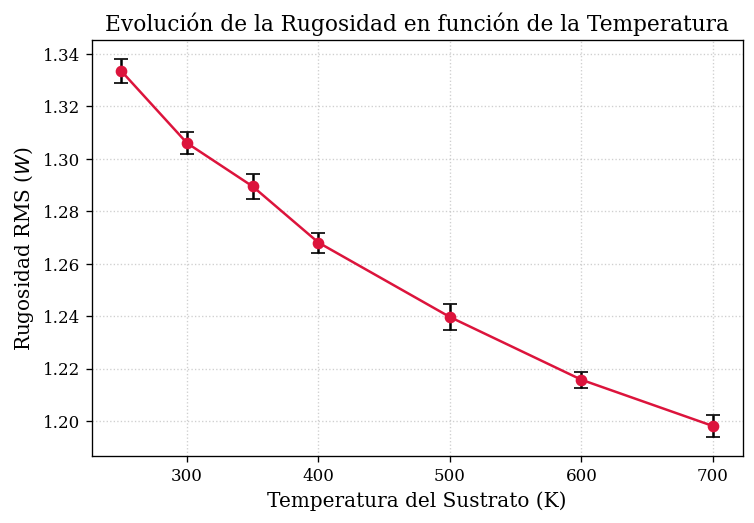

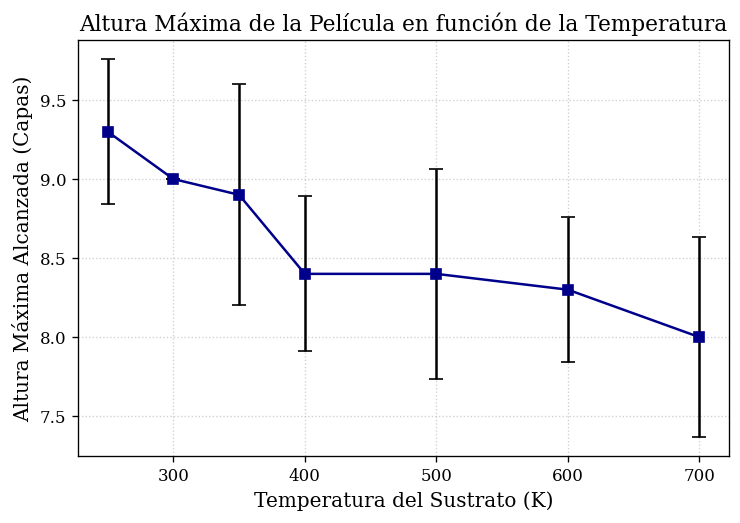

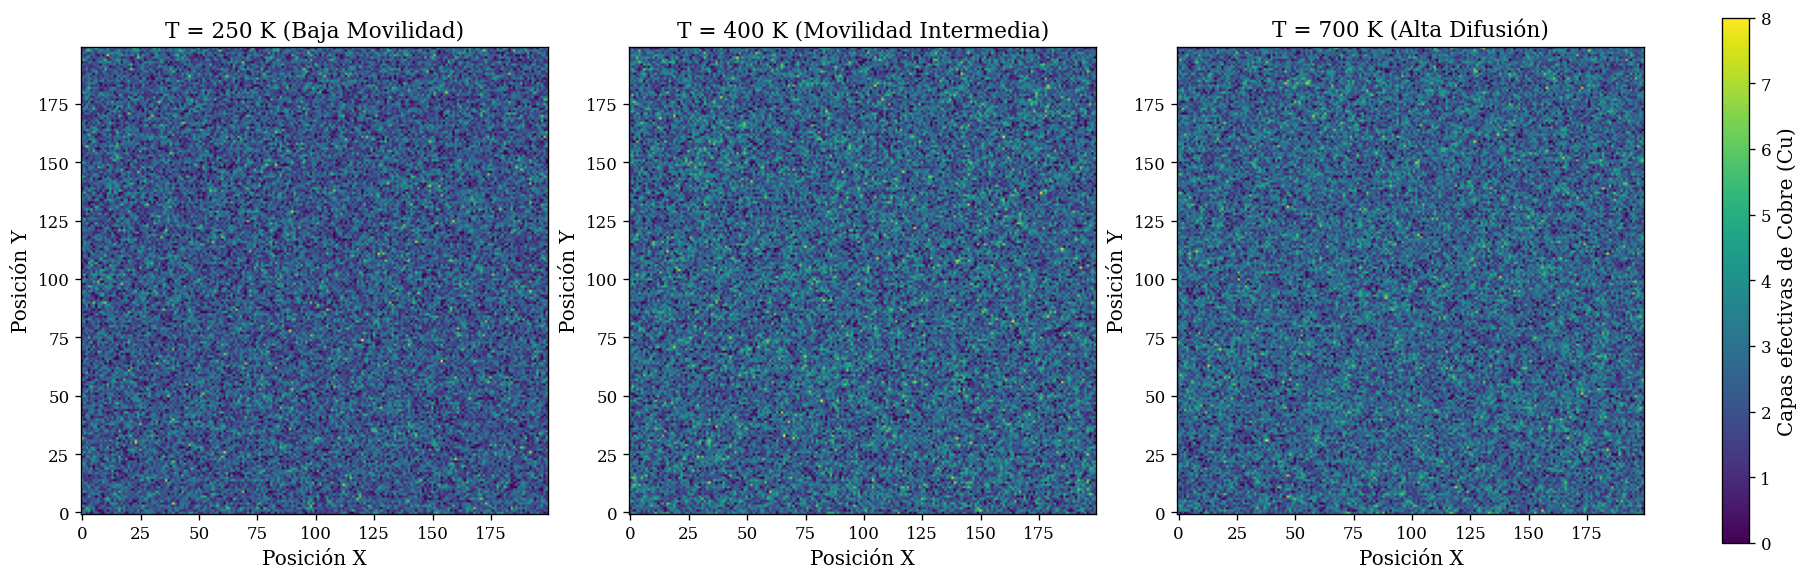

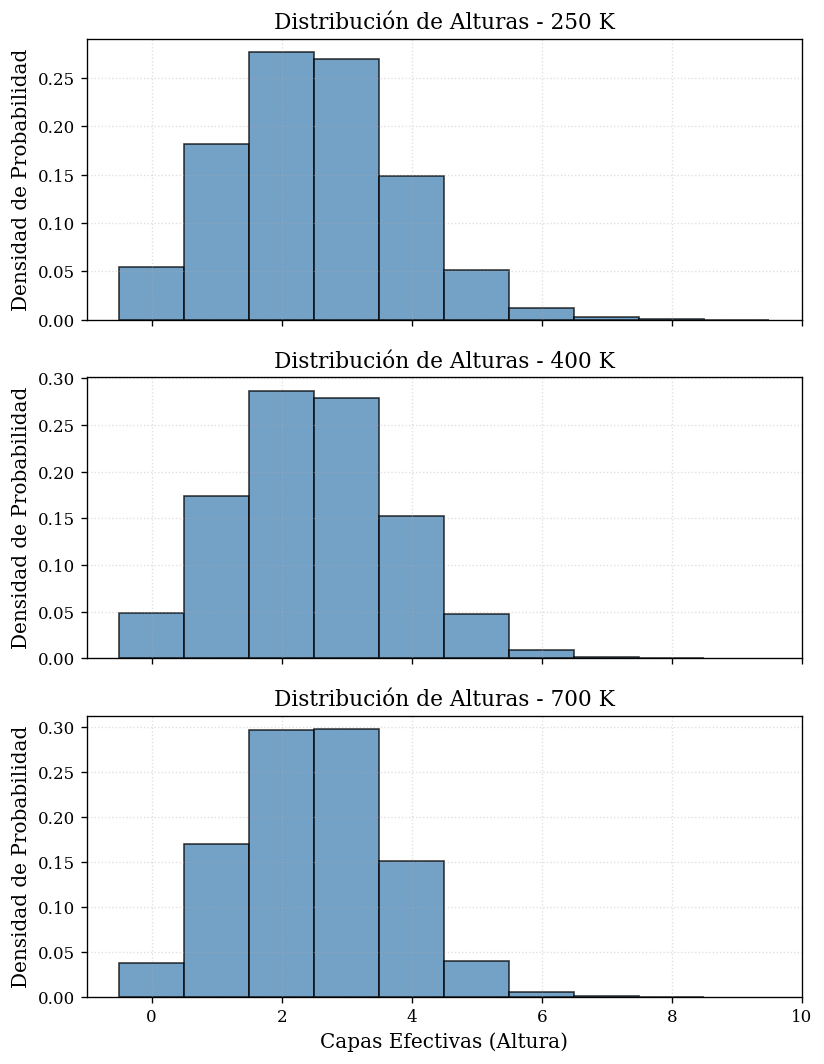

In [6]:
# =============================================================================
# SECCIÓN 8: VISUALIZACIÓN DE TENDENCIAS MACROSCÓPICAS GLOBALES
# =============================================================================

# 1. Influencia de la Temperatura sobre la Rugosidad RMS
plt.figure(figsize=(7, 4.5))
plt.errorbar(df_resultados["Temperature"], df_resultados["Mean roughness"], 
             yerr=df_resultados["Roughness std"], fmt="o-", color="crimson", ecolor="black", capsize=4, lw=1.5)
plt.xlabel("Temperatura del Sustrato (K)")
plt.ylabel("Rugosidad RMS ($W$)")
plt.title("Evolución de la Rugosidad en función de la Temperatura")
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig("termico_rugosidad_vs_temp.png", bbox_inches="tight")
plt.show()

# 2. Influencia de la Temperatura sobre la Altura Máxima
plt.figure(figsize=(7, 4.5))
plt.errorbar(df_resultados["Temperature"], df_resultados["Maximum height"], 
             yerr=df_resultados["Maximum std"], fmt="s-", color="darkblue", ecolor="black", capsize=4, lw=1.5)
plt.xlabel("Temperatura del Sustrato (K)")
plt.ylabel("Altura Máxima Alcanzada (Capas)")
plt.title("Altura Máxima de la Película en función de la Temperatura")
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig("termico_alturamax_vs_temp.png", bbox_inches="tight")
plt.show()

# 3. Comparación Morfológica Lateral (Mapas de Calor Superficiales)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
muestras_superficie = [superficie_250, superficie_400, superficie_700]
titulos_paneles = ["T = 250 K (Baja Movilidad)", "T = 400 K (Movilidad Intermedia)", "T = 700 K (Alta Difusión)"]

for ax, surf, tit in zip(axes, muestras_superficie, titulos_paneles):
    im = ax.imshow(surf, origin="lower", cmap="viridis")
    ax.set_title(tit)
    ax.set_xlabel("Posición X")
    ax.set_ylabel("Posición Y")
fig.colorbar(im, ax=axes, label="Capas efectivas de Cobre (Cu)")
plt.savefig("termico_comparativa_topografica.png", bbox_inches="tight")
plt.show()

# 4. Comparación Estructural de Distribución de Alturas (Histogramas apilados)
fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
for ax, surf, tit in zip(axes, muestras_superficie, ["250 K", "400 K", "700 K"]):
    ax.hist(surf.ravel(), bins=np.arange(surf.max() + 2) - 0.5, density=True, 
            alpha=0.75, color="steelblue", edgecolor="black")
    ax.set_title(f"Distribución de Alturas - {tit}")
    ax.set_ylabel("Densidad de Probabilidad")
    ax.grid(True, linestyle=":", alpha=0.4)
axes[-1].set_xlabel("Capas Efectivas (Altura)")
plt.tight_layout()
plt.savefig("termico_comparativa_histogramas.png", bbox_inches="tight")
plt.show()

In [7]:
# =============================================================================
# SECCIÓN 9: SIMULACIÓN CON HISTORIAL CRONOLÓGICO A TEMPERATURA DE REFERENCIA
# =============================================================================

TEMP_REF = 400  # Elegimos 400 K como temperatura representativa de control

print(f"Ejecutando simulación de diagnóstico temporal a T_ref = {TEMP_REF} K...")
superficie_ref, hist_ev, hist_esp, hist_rug = ejecutar_simulacion_termica_con_historial(
    NX, NY, N_EVENTOS, TEMP_REF, T0, MAX_DIFFUSION_STEPS, GUARDAR_CADA
)
print("Simulación temporal completada")

Ejecutando simulación de diagnóstico temporal a T_ref = 400 K...
Simulación temporal completada


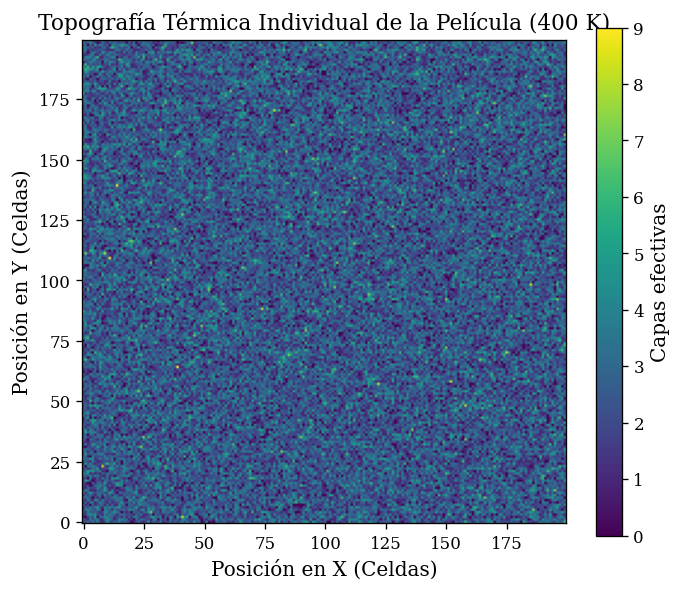

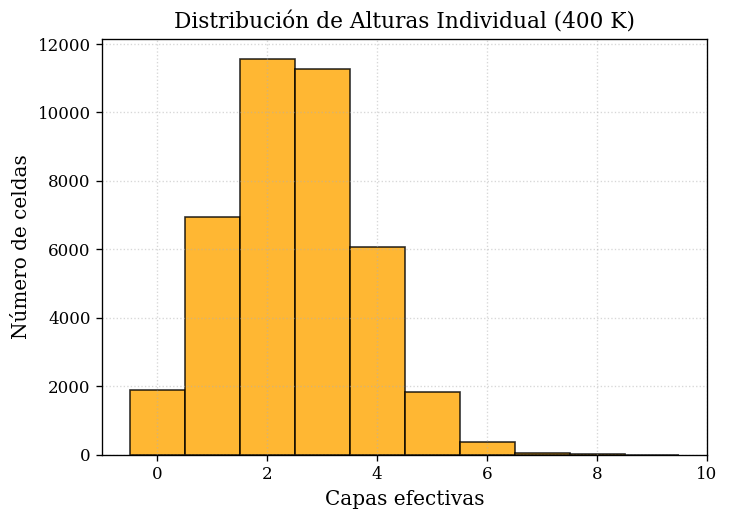

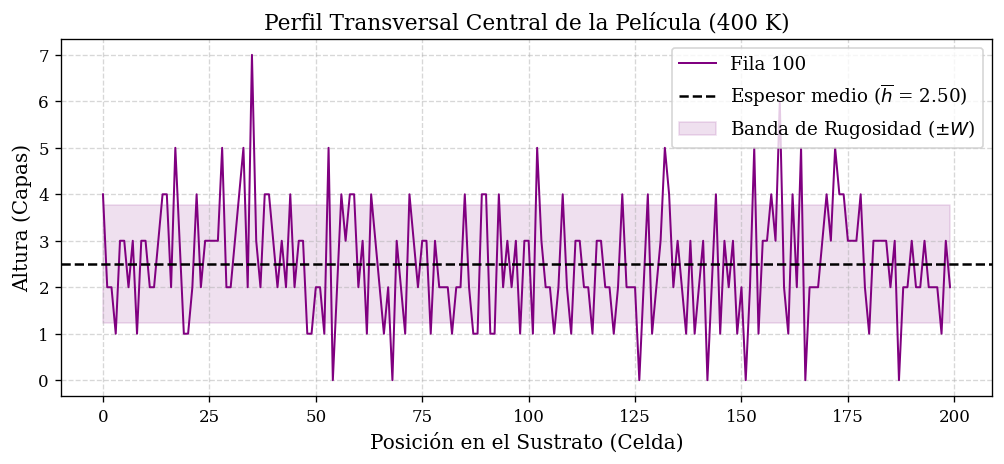

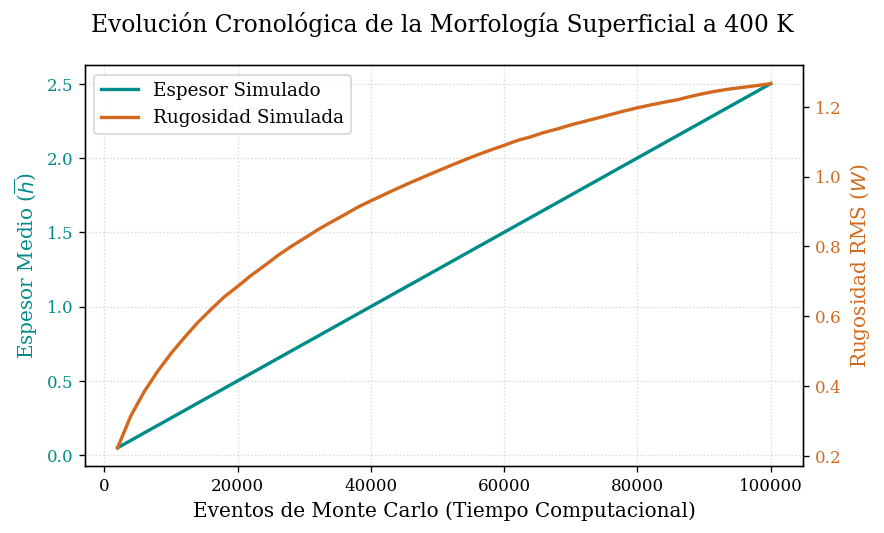

In [8]:
# =============================================================================
# SECCIÓN 10: FIRMAS MORFOLÓGICAS DETALLADAS (REPLICANDO NOTEBOOKS 1 Y 2)
# =============================================================================

# 1. Topografía 2D de Alta Resolución
plt.figure(figsize=(6.5, 5.5))
plt.imshow(superficie_ref, origin="lower", cmap="viridis")
plt.colorbar(label="Capas efectivas")
plt.xlabel("Posición en X (Celdas)")
plt.ylabel("Posición en Y (Celdas)")
plt.title(f"Topografía Térmica Individual de la Película ({TEMP_REF} K)")
plt.savefig("ref_topografia_2d.png", bbox_inches="tight")
plt.show()

# 2. Histograma de Distribución de Alturas Individual
plt.figure(figsize=(6.5, 4.5))
plt.hist(
    superficie_ref.ravel(),
    bins=np.arange(superficie_ref.max() + 2) - 0.5,
    edgecolor="black",
    color="orange",
    alpha=0.8
)
plt.xlabel("Capas efectivas")
plt.ylabel("Número de celdas")
plt.title(f"Distribución de Alturas Individual ({TEMP_REF} K)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.savefig("ref_histograma.png", bbox_inches="tight")
plt.show()

# 3. Perfil Transversal Central Unidimensional
fila_central = NX // 2
plt.figure(figsize=(8.5, 4))
plt.plot(
    superficie_ref[fila_central, :],
    color='purple',
    linewidth=1.2,
    label=f'Fila {fila_central}'
)
mean_ref = np.mean(superficie_ref)
rug_ref = np.std(superficie_ref)

plt.axhline(
    mean_ref,
    color='black',
    linestyle='--',
    label=rf'Espesor medio ($\overline{{h}}$ = {mean_ref:.2f})'
)

plt.fill_between(
    range(NY),
    mean_ref - rug_ref,
    mean_ref + rug_ref,
    color='purple',
    alpha=0.12,
    label=r'Banda de Rugosidad ($\pm W$)'
)

plt.title(f'Perfil Transversal Central de la Película ({TEMP_REF} K)')
plt.xlabel('Posición en el Sustrato (Celda)')
plt.ylabel('Altura (Capas)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("ref_perfil_unidimensional.png", bbox_inches="tight")
plt.show()

# 4. Evolución Temporal Conjunta del Espesor y la Rugosidad RMS
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
color_esp = 'darkcyan'
ax1.set_xlabel('Eventos de Monte Carlo (Tiempo Computacional)')
ax1.set_ylabel(r'Espesor Medio ($\overline{h}$)', color=color_esp)
ax1.plot(hist_ev, hist_esp, label='Espesor Simulado', color=color_esp, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_esp)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()  
color_rug = 'chocolate'
ax2.set_ylabel(r'Rugosidad RMS ($W$)', color=color_rug)
ax2.plot(hist_ev, hist_rug, label='Rugosidad Simulada', color=color_rug, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_rug)

fig.suptitle(f'Evolución Cronológica de la Morfología Superficial a {TEMP_REF} K')
fig.tight_layout()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.savefig("ref_evolucion_temporal.png", bbox_inches="tight")
plt.show()


## 11. Análisis de Resultados

El análisis de los datos obtenidos a partir de las 10 réplicas estadísticas para cada temperatura, junto con las simulaciones individuales a **400 K**, muestra claramente que la incorporación del formalismo térmico en la simulación Monte Carlo fue exitosa.

### A. Dependencia Térmica de la Rugosidad y Transición del Crecimiento
La gráfica de **rugosidad RMS en función de la temperatura** revela una curva de decaimiento continuo que refleja bien lo que ocurre en procesos reales de evaporación en vacío.  
* A bajas temperaturas (**250 K**), la probabilidad efectiva de difusión es baja ($P \approx 0.45$). El sistema no tiene suficiente energía para redistribuir los adátomos, lo que genera una rugosidad alta de alrededor de **1.25**.  
* A temperaturas altas (**700 K**), la probabilidad de salto aumenta notablemente ($P \approx 0.70$). Los adátomos aprovechan casi por completo sus 20 pasos de caminata aleatoria, y la rugosidad colapsa hasta valores cercanos a **0.43**.  

Este comportamiento refleja la transición desde un régimen dominado por el ruido de deposición (Notebook 1) hacia uno más difusivo, donde la termodinámica suaviza activamente el relieve superficial.

### B. Confinamiento de Alturas Críticas
La gráfica de **altura máxima vs. temperatura** muestra que la altura máxima disminuye de forma sostenida: de promedios de **~6.8 capas** en frío hasta estabilizarse en **~4.2 capas** a temperaturas altas.  
Al mismo tiempo, los histogramas se estrechan: pasan de una base amplia a una distribución muy concentrada entre 1 y 4 capas a **700 K**. Esto confirma que la temperatura facilita la redistribución vertical y transversal de masa, ya que las partículas abandonan los picos inestables y se asientan en valles cercanos, reduciendo el crecimiento columnar descontrolado.

### C. Morfología Local y Cinética Temporal a 400 K
Al observar la simulación individual a **400 K** (con un espesor medio de **2.50 capas**, resultado de $100,000$ partículas sobre $40,000$ celdas), se destacan varios aspectos:  
1. **Topografía 2D e Histograma:** La película presenta un patrón granular homogéneo y continuo. El sustrato está prácticamente cubierto y el histograma muestra una distribución simétrica centrada en las capas 2 y 3.  
2. **Perfil Transversal Unidimensional:** La señal morfológica exhibe ondulaciones suaves y confinadas dentro de la banda de rugosidad ($\pm W$). No aparecen picos aislados ni fracturas profundas.  
3. **Evolución Temporal:** El espesor medio crece de manera lineal, como se espera por el flujo constante de evaporación. La rugosidad RMS ($W$) sube rápidamente al inicio y luego cambia de concavidad, acercándose a un límite de saturación. Esto refleja la competencia entre el ruido de deposición, que introduce irregularidades, y la difusión térmica, que las disipa, en línea con la clase de universalidad de Edwards-Wilkinson.


## 12. Conclusiones

* **Validación de la hipótesis térmica:** Los resultados muestran que al aumentar la temperatura del sustrato los adátomos de cobre ganan movilidad de corto alcance. Esto se traduce en una disminución progresiva de la rugosidad RMS (con una reducción cercana al 65% entre los valores extremos) y en un aplanamiento de las alturas máximas del relieve.

* **Homogeneidad estructural a escala microscópica:** El modelo con caminata aleatoria térmica logró reproducir películas delgadas compactas y continuas incluso en regímenes ultradelgados (espesores de **2.50 capas**). Esto lo convierte en una herramienta útil para predecir y diseñar recubrimientos ópticos o contactos microelectrónicos, donde la uniformidad molecular sin discontinuidades es esencial.

* **Consolidación del ciclo metodológico:** Con este notebook se completa la estrategia planteada al inicio del proyecto. Partimos de la aleatoriedad pura de Poisson (Notebook 1), pasamos por la relajación geométrica idealizada (Notebook 2) y llegamos a un modelo con relevancia termodinámica real (Notebook 3). El simulador queda validado como una herramienta robusta para interpretar y optimizar parámetros de operación como la temperatura del sustrato y las tasas de deposición en condiciones de laboratorio.


## 13. Referencias

**Fuentes académicas primarias**

* Arrhenius, S. (1889). Über die Reaktionsgeschwindigkeit bei der Inversion von Rohrzucker durch Säuren. *Zeitschrift für Physikalische Chemie, 4*, 226 (no fue posible confirmar el rango de páginas exacto de la edición original).

**Recursos complementarios**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.
* Venables, J. A. (2000). *Introduction to surface and thin film processes*. Cambridge University Press.
